In [13]:
import pandas as pd
import numpy as np
import re
import nltk
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from transformers import MarianMTModel, MarianTokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
from tqdm import tqdm
from unidecode import unidecode
from sklearn.preprocessing import MinMaxScaler

In [2]:
# clean text
df = pd.read_csv(r"D:\customer-intelligence-engine\data\processed\dl_dataset.csv")

In [3]:
df.head()

,review_id,order_id,review_score,review_comment_message
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,Recebi bem antes do prazo estipulado.
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,Parabéns lojas lannister adorei comprar pela I...
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,aparelho eficiente. no site a marca do aparelh...
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\\n"
4,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,"Vendedor confiável, produto ok e entrega antes..."


In [4]:
df['review_score'] = pd.to_numeric(df['review_score'] , errors = 'coerce')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41045 entries, 0 to 41044
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   review_id               41039 non-null  object 
 1   order_id                40981 non-null  object 
 2   review_score            40976 non-null  float64
 3   review_comment_message  40976 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.3+ MB


In [6]:
df.isnull().sum()

review_id                  6
order_id                  64
review_score              69
review_comment_message    69
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df = df[df['review_score'] != 3]
df['sentiment'] = df['review_score'].apply(lambda x: 1 if x >= 4 else 0 )

In [9]:
def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()                 # lowercase
    text = unidecode(text)                   # remove accents (ótimo → otimo)
    text = re.sub(r"\d+", "", text)          # remove numbers
    text = re.sub(r"[^a-z\s]", "", text)     # remove special characters
    text = re.sub(r"\s+", " ", text).strip() # remove extra spaces
    
    return text

df["clean_review"] = df["review_comment_message"].apply(clean_text)

# remove empty reviews
df = df[df["clean_review"] != ""]


In [10]:
df.head()

,review_id,order_id,review_score,review_comment_message,sentiment,clean_review
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5.0,Recebi bem antes do prazo estipulado.,1,recebi bem antes do prazo estipulado
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5.0,Parabéns lojas lannister adorei comprar pela I...,1,parabens lojas lannister adorei comprar pela i...
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4.0,aparelho eficiente. no site a marca do aparelh...,1,aparelho eficiente no site a marca do aparelho...
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4.0,"Mas um pouco ,travando...pelo valor ta Boa.\r\\n",1,mas um pouco travandopelo valor ta boa
4,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5.0,"Vendedor confiável, produto ok e entrega antes...",1,vendedor confiavel produto ok e entrega antes ...


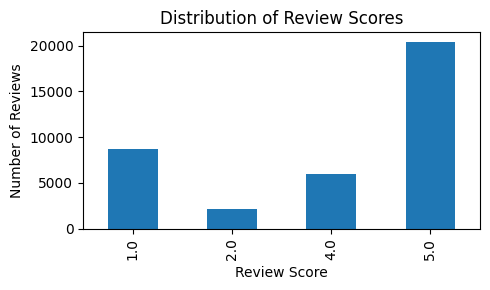

In [15]:
plt.figure(figsize=(5,3))

df["review_score"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [11]:
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [12]:
def batch_predict(texts, batch_size = 32):
    all_predictions = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i : i + batch_size].tolist()

        inputs = tokenizer(
            batch,
            return_tensors = "pt",
            padding = True,
            truncation = True,
            max_length = 128
        )

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim = 1) + 1

        all_predictions.extend(preds.tolist())
        
    return all_predictions

In [13]:
df.loc[:, 'bert_rating'] = batch_predict(df['clean_review'])

100%|██████████████████████████████████████████████████████████████████████████████| 1164/1164 [40:56<00:00,  2.11s/it]


In [14]:
def convert_to_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return "positive"

df.loc[:, 'bert_sentiment'] = df['bert_rating'].apply(convert_to_sentiment)

In [15]:
df.head()

,review_id,order_id,review_score,review_comment_message,sentiment,clean_review,bert_rating,bert_sentiment
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5.0,Recebi bem antes do prazo estipulado.,1,recebi bem antes do prazo estipulado,3,neutral
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5.0,Parabéns lojas lannister adorei comprar pela I...,1,parabens lojas lannister adorei comprar pela i...,5,positive
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4.0,aparelho eficiente. no site a marca do aparelh...,1,aparelho eficiente no site a marca do aparelho...,3,neutral
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4.0,"Mas um pouco ,travando...pelo valor ta Boa.\r\\n",1,mas um pouco travandopelo valor ta boa,3,neutral
4,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5.0,"Vendedor confiável, produto ok e entrega antes...",1,vendedor confiavel produto ok e entrega antes ...,4,positive


In [16]:
def actual_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else: 
        return "positive"

df.loc[:, "actual_sentiment"] = df["review_score"].apply(actual_sentiment)

In [17]:
df.head()

,review_id,order_id,review_score,review_comment_message,sentiment,clean_review,bert_rating,bert_sentiment,actual_sentiment
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5.0,Recebi bem antes do prazo estipulado.,1,recebi bem antes do prazo estipulado,3,neutral,positive
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5.0,Parabéns lojas lannister adorei comprar pela I...,1,parabens lojas lannister adorei comprar pela i...,5,positive,positive
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4.0,aparelho eficiente. no site a marca do aparelh...,1,aparelho eficiente no site a marca do aparelho...,3,neutral,positive
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4.0,"Mas um pouco ,travando...pelo valor ta Boa.\r\\n",1,mas um pouco travandopelo valor ta boa,3,neutral,positive
4,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5.0,"Vendedor confiável, produto ok e entrega antes...",1,vendedor confiavel produto ok e entrega antes ...,4,positive,positive


In [18]:
print(classification_report(df['actual_sentiment'] , df['bert_sentiment']))

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    negative       0.70      0.89      0.79     10877
     neutral       0.00      0.00      0.00         0
    positive       0.97      0.75      0.84     26367

    accuracy                           0.79     37244
   macro avg       0.56      0.55      0.54     37244
weighted avg       0.89      0.79      0.83     37244



C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
df[df['bert_sentiment'] != df['actual_sentiment']].head()

,review_id,order_id,review_score,review_comment_message,sentiment,clean_review,bert_rating,bert_sentiment,actual_sentiment
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5.0,Recebi bem antes do prazo estipulado.,1,recebi bem antes do prazo estipulado,3,neutral,positive
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4.0,aparelho eficiente. no site a marca do aparelh...,1,aparelho eficiente no site a marca do aparelho...,3,neutral,positive
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4.0,"Mas um pouco ,travando...pelo valor ta Boa.\r\\n",1,mas um pouco travandopelo valor ta boa,3,neutral,positive
8,0e0190b9db53b689b285d3f3916f8441,79832b7cb59ac6f887088ffd686e1d5e,5.0,obrigado pela atençao amim dispensada,1,obrigado pela atencao amim dispensada,1,negative,positive
13,c92cdd7dd544a01aa35137f901669cdf,37e7875cdce5a9e5b3a692971f370151,4.0,Recebi exatamente o que esperava. As demais en...,1,recebi exatamente o que esperava as demais enc...,3,neutral,positive


In [20]:
df['review_score'].value_counts()

review_score
5.0    20441
1.0     8735
4.0     5926
2.0     2142
Name: count, dtype: int64

In [21]:
order_items = pd.read_csv(r"D:\customer-intelligence-engine\data\raw\olist_order_items_dataset.csv")

In [22]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [23]:
df = df.merge(
    order_items[['order_id', 'seller_id']],
    on = 'order_id',
    how = 'left'
)

In [24]:
df.head()

,review_id,order_id,review_score,review_comment_message,sentiment,clean_review,bert_rating,bert_sentiment,actual_sentiment,seller_id
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5.0,Recebi bem antes do prazo estipulado.,1,recebi bem antes do prazo estipulado,3,neutral,positive,a1043bafd471dff536d0c462352beb48
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5.0,Parabéns lojas lannister adorei comprar pela I...,1,parabens lojas lannister adorei comprar pela i...,5,positive,positive,989becdce12ebc39863c2bceab6f3ca1
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4.0,aparelho eficiente. no site a marca do aparelh...,1,aparelho eficiente no site a marca do aparelho...,3,neutral,positive,05ff92fedb5be47920fea08e501238b9
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4.0,"Mas um pouco ,travando...pelo valor ta Boa.\r\\n",1,mas um pouco travandopelo valor ta boa,3,neutral,positive,db4350fd57ae30082dec7acbaacc17f9
4,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5.0,"Vendedor confiável, produto ok e entrega antes...",1,vendedor confiavel produto ok e entrega antes ...,4,positive,positive,974cf2cb8f4b7add98709c30df02fe10


In [25]:
seller_sentiment = df.groupby("seller_id").agg(
    total_reviews = ('bert_sentiment' , 'count' ),
    negative_reviews = ('bert_sentiment' , lambda x : (x == 'negative').sum() ),
    positive_reviews = ('bert_sentiment' , lambda x : (x == 'positive').sum() )
).reset_index()

seller_sentiment['negative_rate'] = (seller_sentiment['negative_reviews'] / seller_sentiment['total_reviews'])

In [26]:
seller_sentiment

,seller_id,total_reviews,negative_reviews,positive_reviews,negative_rate
0,0015a82c2db000af6aaaf3ae2ecb0532,1,1,0,1.000000
1,001cca7ae9ae17fb1caed9dfb1094831,108,36,56,0.333333
2,001e6ad469a905060d959994f1b41e4f,1,1,0,1.000000
3,002100f778ceb8431b7a1020ff7ab48f,14,6,6,0.428571
4,004c9cd9d87a3c30c522c48c4fc07416,59,17,34,0.288136
...,...,...,...,...,...
2508,ffcfefa19b08742c5d315f2791395ee5,1,1,0,1.000000
2509,ffdd9f82b9a447f6f8d4b91554cc7dd3,10,3,5,0.300000
2510,ffeee66ac5d5a62fe688b9d26f83f534,8,2,6,0.250000
2511,fffd5413c0700ac820c7069d66d98c89,26,13,9,0.500000


In [27]:
df = df.merge(
    seller_sentiment[['seller_id','negative_rate']],
    on = 'seller_id',
    how = 'left'
)
df['negative_rate'] = df['negative_rate'].fillna(0)

In [28]:
scaler = MinMaxScaler()
df['inv_negative_rate'] = 1 - df['negative_rate']
df['norm_negative'] = scaler.fit_transform(df[['inv_negative_rate']])

In [29]:
df.head()

,review_id,order_id,review_score,review_comment_message,sentiment,clean_review,bert_rating,bert_sentiment,actual_sentiment,seller_id,negative_rate,inv_negative_rate,norm_negative
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5.0,Recebi bem antes do prazo estipulado.,1,recebi bem antes do prazo estipulado,3,neutral,positive,a1043bafd471dff536d0c462352beb48,0.320144,0.679856,0.679856
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5.0,Parabéns lojas lannister adorei comprar pela I...,1,parabens lojas lannister adorei comprar pela i...,5,positive,positive,989becdce12ebc39863c2bceab6f3ca1,0.375000,0.625000,0.625000
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4.0,aparelho eficiente. no site a marca do aparelh...,1,aparelho eficiente no site a marca do aparelho...,3,neutral,positive,05ff92fedb5be47920fea08e501238b9,0.210526,0.789474,0.789474
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4.0,"Mas um pouco ,travando...pelo valor ta Boa.\r\\n",1,mas um pouco travandopelo valor ta boa,3,neutral,positive,db4350fd57ae30082dec7acbaacc17f9,0.435484,0.564516,0.564516
4,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5.0,"Vendedor confiável, produto ok e entrega antes...",1,vendedor confiavel produto ok e entrega antes ...,4,positive,positive,974cf2cb8f4b7add98709c30df02fe10,0.214286,0.785714,0.785714


In [30]:
# col = df.pop('seller_id')
# df.insert(0,'seller_id', col)

In [31]:
df['seller_health_index_v2'] = (
    0.30 * df['norm_revenue'] + 
    0.15 * df['norm_orders'] + 
    0.20 * df['norm_review'] + 
    0.15 * df['norm_late'] + 
    0.20 * df['norm_negative']
)

KeyError: 'norm_revenue'

In [ ]:
print(df.columns)
print(seller_sentiment.columns)